# Diamond Price Optimization & Statistical Confidence Interval Analysis

This notebook analyzes 5,000 diamond observations to estimate mean prices across different cut qualities and calculate confidence intervals for cut proportions to assist jewelry retail pricing optimization.

In [2]:
# Cell 2: Imports and visualization setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load Dataset
Locating and loading all data sheets from `data/C2M3_GradedLab_Diamond_prices.xlsx`.

In [4]:
# Cell 4: Read dataset via memory buffer to bypass file permission locks
import os
import io
import pandas as pd

file_name = 'C2M3_GradedLab_Diamond_prices.xlsx'
file_path = None

for search_dir in ['.', '..', 'data', '../data']:
    for root, dirs, files in os.walk(search_dir):
        if file_name in files:
            file_path = os.path.join(root, file_name)
            break
    if file_path:
        break

if file_path:
    print(f"Dataset found at: {os.path.abspath(file_path)}")
    # Read file into memory buffer to prevent file lock issues
    with open(file_path, 'rb') as f:
        file_buffer = io.BytesIO(f.read())
        
    xls = pd.ExcelFile(file_buffer, engine='openpyxl')
    df_all = pd.read_excel(xls, sheet_name='Data')
    df_premium = pd.read_excel(xls, sheet_name='Data - Premium')
    df_fair = pd.read_excel(xls, sheet_name='Data - Fair')

    print(f"Loaded {len(df_all):,} main records, {len(df_premium):,} premium records, {len(df_fair):,} fair records.")
    display(df_all.head())
else:
    raise FileNotFoundError(f"Could not locate {file_name} in project directory.")

Dataset found at: c:\Users\AVIRAJ\OneDrive\Desktop\Pyhton Project\diamond-price-optimization\data\C2M3_GradedLab_Diamond_prices.xlsx
Loaded 5,000 main records, 1,305 premium records, 147 fair records.


,carat,cut,color,clarity,depth,table,price,x,y,z
0,1.06,Premium,E,SI1,63.0,56.0,4689,6.54,6.45,4.09
1,1.71,Ideal,G,VVS2,62.1,55.0,18599,7.63,7.66,4.75
2,1.51,Good,G,VS2,63.3,60.0,12756,7.20,7.28,4.58
3,0.80,Premium,F,VS2,59.7,58.0,3285,6.02,5.97,3.58
4,0.30,Good,D,SI1,63.1,56.0,515,4.24,4.28,2.69


## 2. Exercise 1 — Mean Price & 95% Confidence Intervals (z = 1.96)
Calculating sample mean (\(\bar{x}\)), sample standard deviation (\(s\)), sample size (\(n\)), margin of error (\(\text{MoE}\)), and 95% confidence intervals for All Diamonds, Premium Cut, and Fair Cut.

In [5]:
# Cell 6: Exercise 1 Calculations
def calculate_mean_ci(data_series, group_name, z=1.96):
    x_bar = data_series.mean()
    s = data_series.std(ddof=1)
    n = len(data_series)
    moe = z * (s / np.sqrt(n))
    lower = x_bar - moe
    upper = x_bar + moe
    return {
        'Group': group_name,
        'Mean (x̄)': round(x_bar, 4),
        'Std Dev (s)': round(s, 4),
        'Sample Size (n)': n,
        'z-score': z,
        'Margin of Error': round(moe, 4),
        '95% CI Lower': round(lower, 4),
        '95% CI Upper': round(upper, 4)
    }

ex1_results = pd.DataFrame([
    calculate_mean_ci(df_all['price'], 'All Diamonds'),
    calculate_mean_ci(df_premium['price'], 'Premium Cut'),
    calculate_mean_ci(df_fair['price'], 'Fair Cut')
])

display(ex1_results)

,Group,Mean (x̄),Std Dev (s),Sample Size (n),z-score,Margin of Error,95% CI Lower,95% CI Upper
0,All Diamonds,3862.4168,3977.5602,5000,1.96,110.2523,3752.1645,3972.6691
1,Premium Cut,4524.1441,4351.3958,1305,1.96,236.0910,4288.0531,4760.2350
2,Fair Cut,4333.5578,3277.9444,147,1.96,529.9062,3803.6516,4863.4640


## 3. Exercise 2 — Cut Proportions & 90% Confidence Intervals (z = 1.645)
Estimating the proportion (\(\hat{p}\)) of expected inventory for high-demand cuts ('Premium' or 'Ideal') vs. low-demand cuts ('Fair').

In [6]:
# Cell 8: Exercise 2 Calculations
total_n = len(df_all)
premium_ideal_count = df_all['cut'].isin(['Premium', 'Ideal']).sum()
fair_count = (df_all['cut'] == 'Fair').sum()

def calculate_prop_ci(count, n, group_name, z=1.645):
    p_hat = count / n
    moe = z * np.sqrt((p_hat * (1 - p_hat)) / n)
    lower = p_hat - moe
    upper = p_hat + moe
    return {
        'Cut Category': group_name,
        'Count': count,
        'Total (n)': n,
        'Proportion (p̂)': round(p_hat, 4),
        'z-score': z,
        'Margin of Error': round(moe, 6),
        '90% CI Lower': round(lower, 6),
        '90% CI Upper': round(upper, 6)
    }

ex2_results = pd.DataFrame([
    calculate_prop_ci(premium_ideal_count, total_n, 'Premium or Ideal'),
    calculate_prop_ci(fair_count, total_n, 'Fair')
])

display(ex2_results)

,Cut Category,Count,Total (n),Proportion (p̂),z-score,Margin of Error,90% CI Lower,90% CI Upper
0,Premium or Ideal,3316,5000,0.6632,1.645,0.010995,0.652205,0.674195
1,Fair,147,5000,0.0294,1.645,0.003930,0.025470,0.033330


## 4. Visualizations & Visual Export
Generating and saving plot exports to the `visuals/` directory.

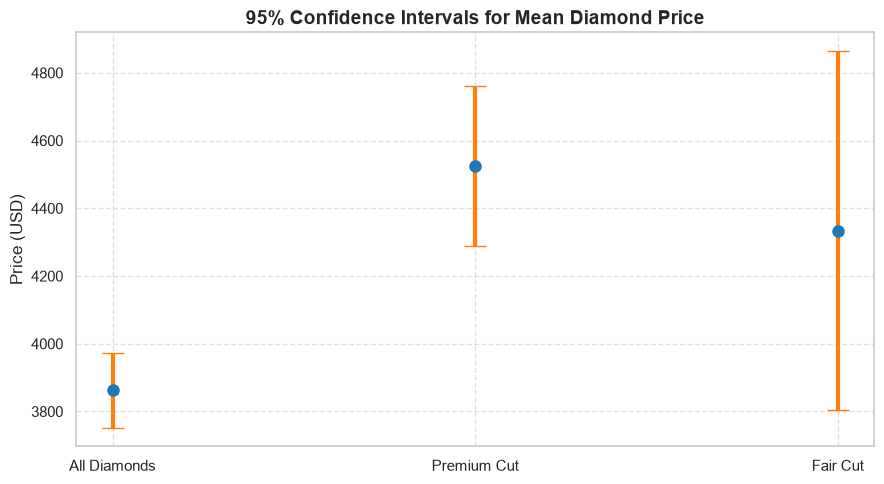

C:\Users\AVIRAJ\AppData\Local\Temp\ipykernel_32072\2671415235.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cut_counts.index, y=cut_counts.values, palette='Blues_r')


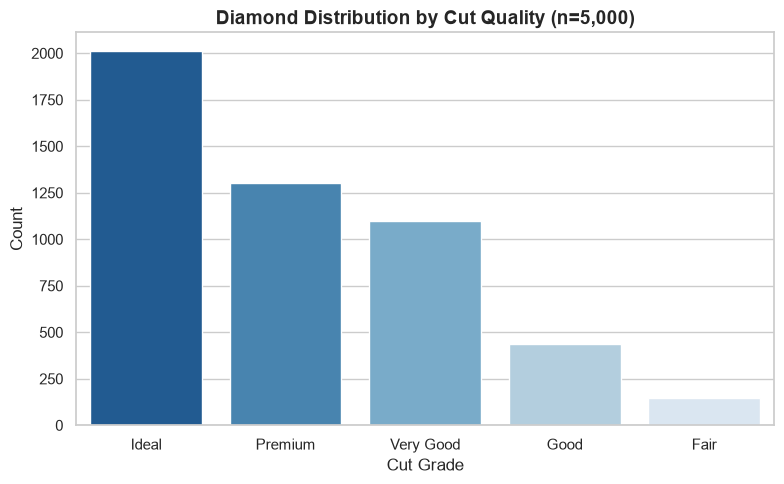

Visualizations saved to: c:\Users\AVIRAJ\OneDrive\Desktop\Pyhton Project\diamond-price-optimization\visuals


In [7]:
# Cell 10: Generate and save plots
output_dir = '../visuals' if os.path.exists('../visuals') else 'visuals'
os.makedirs(output_dir, exist_ok=True)

# Plot 1: Mean Price Confidence Intervals
plt.figure(figsize=(9, 5))
groups = ex1_results['Group']
means = ex1_results['Mean (x̄)']
errors = ex1_results['Margin of Error']

plt.errorbar(groups, means, yerr=errors, fmt='o', color='#1f77b4', ecolor='#ff7f0e', elinewidth=3, capsize=8, markersize=8)
plt.title('95% Confidence Intervals for Mean Diamond Price', fontsize=14, fontweight='bold')
plt.ylabel('Price (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'price_ci_by_cut.png'), dpi=300)
plt.show()

# Plot 2: Cut Proportions
plt.figure(figsize=(8, 5))
cut_counts = df_all['cut'].value_counts()
sns.barplot(x=cut_counts.index, y=cut_counts.values, palette='Blues_r')
plt.title('Diamond Distribution by Cut Quality (n=5,000)', fontsize=14, fontweight='bold')
plt.xlabel('Cut Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'cut_proportion_ci.png'), dpi=300)
plt.show()

print(f"Visualizations saved to: {os.path.abspath(output_dir)}")